# Задание 7: Деревья. Случайный лес


## Часть 1: Основы построения решающие дерева (1.5 балла)

В этой части все расчёты необходимо реализовывать в виде запрограммированных формул, например, на `numpy`. **Нельзя использовать готовые реализации**. Например, если в задании требуется рассчитать энтропию, то требуется в каком-то виде релизовать расчёт по формуле, но нельзя использовать готовую реализацию `some_module.entropy()`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

**Задание 1.1 (0.5 балла)** Пусть известно, что в вершину решающего дерева попали 10 объектов, 8 из которых имеют метку класса $k_1$, а 2 имеют метку класса $k_2$. Рассчитайте энтропию такого распределения классов (с натуральным логарифмом). Ответ округлите до двух знаков после запятой.

In [2]:
import math

p1 = 0.8
p2 = 0.2

entropy = -(p1*math.log(p1) + p2*math.log(p2))
print(f"{entropy:.4f}")

0.5004


**Задание 1.2 (0.5 балла)** Пусть дополнительно известно, что вершина из предыдущего задания не является листовой и возможно такое разбиение, что в левое поддерево попадут все объекты класса $k_1$, а в правое - класса $k_2$. Посчитайте критерий информативности:

$$
Q(R_m, j, t) = H(R_m) - \frac{|R_\ell|}{|R_m|}H(R_\ell) - \frac{|R_r|}{|R_m|}H(R_r),
$$

где $R_m$ - множество объектов в разбиваемой вершине, $j$ - номер признака, по которому происходит разбиение, $t$ - порог разбиения, $R_\ell$ - множество объектов в левом поддереве, $R_r$ - множество объектов в правом поддереве.

Теперь в качестве $H(R)$ будем использовать индекс Джини:

$$
H(R) = \sum_{k=1}^J p_k(1-p_k),
$$
где $J$ – общее количество классов (в нашем случае, $J = 2$).

Ответ округлите до двух знаков после запятой.

In [3]:
gini = p1*(1-p1) + p2*(1-p2)
print(f"{gini:.4f}")

0.3200


**Задание 1.3 (0.5 балла)** Пусть при построении дерева образовалась листовая вершина с 10 объектами, значения целевой переменной для которых следующие: [1, 10, 5, 18, 100, 30, 50, 61, 84, 47] (решается задача регрессии). Чему будут равны предсказания модели для этих объектов?

In [4]:
print(np.array([1, 10, 5, 18, 100, 30, 50, 61, 84, 47]).mean())

40.6


## Часть 2: Решающие деревья (4.5 балла)

В этой части мы напишем и протестируем собственную реализацию решающего дерева.

In [5]:
from collections import Counter
from typing import Dict, List, Tuple, Union

**Задание 2.1 (1.5 балла)** Реализуйте функцию `find_best_split()`, которая должна находить оптимальное разбиение подмножества обучающей выборки в соответствии с информационным критерием из **Задания 1.2**. В качестве меры хаотичности $H(R)$ для задачи регрессии испольуйте дисперсию подвыборки, а для задачи классификации – критерий Джини (определён в том же задании).

Для категориальных признаков применяется наивный алгоритм разбиения: мы пытаемся найти одно значение, разбиение по которому сильнее всего увеличит критерий информативности. Иными словами, объекты с конкретным значением признака отправляем в левое поддерево, остальные - в правое. Обратите внимание, что это далеко не оптимальные способ учёта категориальных признаков. Например, можно было бы на каждое значение категориального признака создавать отдельное поддерево или использовать более сложные подходы. Подробнее об этом можно прочитать в конспектах [лекций](https://github.com/esokolov/ml-course-hse/blob/master/2019-fall/lecture-notes/lecture07-trees.pdf) по машинному обучению на ПМИ (раздел «Учёт категориальных признаков»).

В качестве подсказок реализации можете пользоваться кодом из бонусной части семинара по решающим деревьям.

**Бонус:** Разрешается делать цикл для перебора порогов, но возможна имплементация без него. За имплементацию без цикла – **бонус 1 балл**.

In [6]:
def gini(y: np.ndarray) -> float:
  _, counts = np.unique(y, return_counts=True)
  probs = counts / counts.sum()
  return 1 - np.sum(probs ** 2)

def variance(y: np.ndarray) -> float:
  return np.var(y) if len(y) > 0 else 0

def find_best_split(
    feature_vector: Union[np.ndarray, pd.DataFrame],
    target_vector: Union[np.ndarray, pd.Series],
    task: str = "classification",
    feature_type: str = "real"
) -> Tuple[np.ndarray, np.ndarray, float, float]:
    """
    Указания:
    * Пороги, приводящие к попаданию в одно из поддеревьев пустого множества объектов, не рассматриваются.
    * В качестве порогов, нужно брать среднее двух сосдених (при сортировке) значений признака
    * Поведение функции в случае константного признака может быть любым.
    * При одинаковых приростах Джини или дисперсии нужно выбирать минимальный сплит.
    * За наличие в функции циклов балл будет снижен. Векторизуйте! :)

    :param feature_vector: вещественнозначный вектор значений признака
    :param target_vector: вектор классов объектов,  len(feature_vector) == len(target_vector)
    :param task: либо `classification`, либо `regression`
    :param feature_type: либо `real`, либо `categorical`

    :return thresholds: отсортированный по возрастанию вектор со всеми возможными порогами, по которым объекты можно
     разделить на две различные подвыборки, или поддерева
    :return ginis: вектор со значениями критерия Джини для каждого из порогов в thresholds len(ginis) == len(thresholds)
    :return threshold_best: оптимальный порог (число)
    :return gini_best: оптимальное значение критерия Джини (число)
    """
    feature_vector, target_vector = np.asarray(feature_vector), np.asarray(target_vector)

    if feature_type == 'real':

      sorted_idx = np.argsort(feature_vector)
      feature_vector, target_vector = feature_vector[sorted_idx], target_vector[sorted_idx]

      thresholds = (feature_vector[:-1] + feature_vector[1:]) / 2
      thresholds = np.unique(thresholds)

      impurity_func = gini if task == 'classification' else variance
      H_root = impurity_func(target_vector)

      split_mask = feature_vector[:, None] < thresholds

    if feature_type == 'categorical':

      unique_values = np.unique(feature_vector)
      thresholds = unique_values

      impurity_func = gini if task == 'classification' else variance
      H_root = impurity_func(target_vector)

      split_mask = feature_vector[:, None] == thresholds

    left_counts = split_mask.sum(axis=0)
    right_counts = len(feature_vector) - left_counts

    left_impurity = np.array([impurity_func(target_vector[split_mask[:, i]]) for i in range(len(thresholds))])
    right_impurity = np.array([impurity_func(target_vector[~split_mask[:, i]]) for i in range(len(thresholds))])

    ginis = H_root - (left_counts / len(feature_vector)) * left_impurity - (right_counts / len(feature_vector)) * right_impurity

    best_idx = np.argmax(ginis[::-1])
    best_idx = len(ginis) - 1 - best_idx
    threshold_best = thresholds[best_idx]
    gini_best = ginis[best_idx]


    return thresholds, ginis, threshold_best, gini_best

Эту функцию можно протестировать на датасете `California`.

In [7]:
from sklearn.datasets import fetch_california_housing

In [8]:
data = fetch_california_housing()
X = pd.DataFrame(data=data["data"], columns=data["feature_names"])
y = data["target"]
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [9]:
y

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894])

Выведите график зависимости значения критерия ошибки от порогового значения при разбиении вершины по признаку `MedInc`.

Лучший порог 5.03515
Лучшая дисперсия 0.4127513862016767


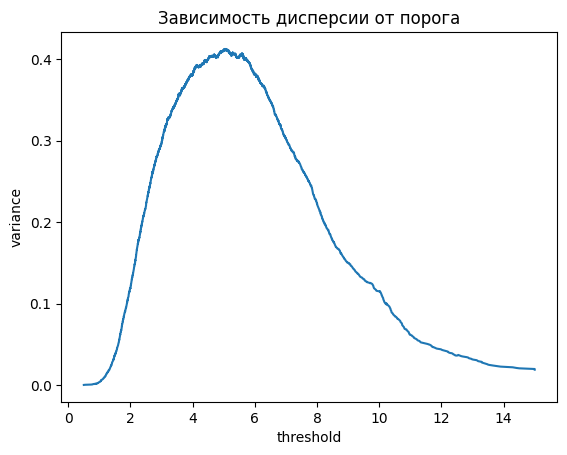

In [10]:
thresholds, variances, threshold_best, variance_best = find_best_split(X['MedInc'].to_numpy(), y, 'regression', 'real')
print('Лучший порог', threshold_best)
print('Лучшая дисперсия', variance_best)
plt.plot(thresholds, variances)
plt.title('Зависимость дисперсии от порога')
plt.ylabel('variance')
plt.xlabel('threshold')
plt.yticks()
plt.xticks()
plt.show()

**Задание 2.2 (1 балл)** Разберитесь с написанным кодом решающего дерева, заполните пропуски в коде и реализуйте недостающий метод `_predict_node()`.

Построение дерева осуществляется согласно базовому жадному алгоритму, предложенному в лекции в разделе «Построение дерева».
- **Выбор лучшего разбиения** необходимо производить по критерию Джини.
- **Критерий останова:** все объекты в листе относятся к одному классу или ни по одному признаку нельзя разбить выборку.
- **Ответ в листе:** наиболее часто встречающийся класс в листе.

В задаче также предлагается получить два бонуса, по баллу на каждый!

- **Реализуйте способ обрабатывать пропуски в даннх и реализуйте его, пояснив свои действия.**
- **Реализуйте метод оценки важности признаков.**

In [11]:
class DecisionTree:

    def __init__(
        self,
        feature_types: Union[List[str], np.ndarray],
        max_depth: int = None,
        min_samples_split: int = None,
        min_samples_leaf: int = None,
        task: str = "classification"
    ) -> None:

        if np.any(list(map(lambda x: x != "real" and x != "categorical", feature_types))):
            raise ValueError("There is unknown feature type")

        # В этой переменной будем хранить узлы решающего дерева. Каждая вершина хранит в себе идентификатор того,
        # является ли она листовой. Листовые вершины хранят значение класса для предсказания, нелистовые - правого и
        # левого детей (поддеревья для продолжения процедуры предсказания)
        self._tree = {}

        # типы признаков (категориальные или числовые)
        self._feature_types = feature_types

        # гиперпараметры дерева
        self._max_depth = max_depth
        self._min_samples_split = min_samples_split
        self._min_samples_leaf = min_samples_leaf
        self.task = task

        # Переменная, если вы решите делать бонус
        self._feature_importances = {}


    def _fit_node(
        self,
        sub_X: np.ndarray,
        sub_y: np.ndarray,
        node: dict
    ) -> None:

        # критерий останова
        if np.all(sub_y == sub_y[0]):
            node["type"] = "terminal"
            node["class"] = sub_y[0]
            return

        feature_best, threshold_best, gini_best, split = None, None, None, None
        for feature in range(sub_X.shape[1]):
            feature_type = self._feature_types[feature]
            categories_map = {}

            # подготавливаем признак для поиска оптимального порога
            if feature_type == "real":
                feature_vector = sub_X[:, feature]
            elif feature_type == "categorical":
                # здесь могла быть реализация более сложного подхода к обработке категориального признака
                feature_vector = sub_X[:, feature]


            # ищем оптимальный порог
            _, _, threshold, gini = find_best_split(feature_vector, sub_y, self.task, feature_type)

            if gini_best is None or gini > gini_best:
                feature_best = feature
                gini_best = gini

                # split - маска на объекты, которые должны попасть в левое поддерево
                if feature_type == "real":
                    threshold_best = threshold
                    split = sub_X[:, feature_best] < threshold_best
                elif feature_type == "categorical":
                    # в данной реализации это просто значение категории
                    threshold_best = threshold
                    split = sub_X[:, feature_best] == threshold_best
                else:
                    raise ValueError

                if np.isnan(sub_X[:, feature_best]).any():
                  split_nan = np.isnan(sub_X[:, feature_best])
                  left_ratio = np.sum(split) / len(split)

                  left_add = np.random.rand(np.sum(split_nan)) < left_ratio
                  right_add = ~left_add

                  split[split_nan] = left_add


        # записываем полученные сплиты в атрибуты класса
        if feature_best is None:
            node["type"] = "terminal"
            node["class"] = Counter(sub_y).most_common(1)[0][0]
            return

        node["type"] = "nonterminal"

        node["feature_split"] = feature_best
        if self._feature_types[feature_best] == "real":
            node["threshold"] = threshold_best
        elif self._feature_types[feature_best] == "categorical":
            node["category_split"] = threshold_best
        else:
            raise ValueError

        node["left_child"], node["right_child"] = {}, {}
        self._fit_node(sub_X[split], sub_y[split], node["left_child"])
        self._fit_node(sub_X[np.logical_not(split)], sub_y[np.logical_not(split)], node["right_child"])

    def _predict_node(self, x: np.ndarray, node: dict) -> int:
        """
        Предсказание начинается с корневой вершины дерева и рекурсивно идёт в левое или правое поддерево в зависимости от значения
        предиката на объекте. Листовая вершина возвращает предсказание.
        :param x: np.array, элемент выборки
        :param node: dict, вершина дерева
        """
        if node["type"] == "terminal":
          return node["class"]

        feature_value = x[node["feature_split"]]

        if self._feature_types[node["feature_split"]] == "real":
          if feature_value < node["threshold"]:
            return self._predict_node(x, node["left_child"])
          else:
            return self._predict_node(x, node["right_child"])

        if self._feature_types[node["feature_split"]] == "categorical":
          if feature_value == node["category_split"]:
            return self._predict_node(x, node["left_child"])
          else:
            return self._predict_node(x, node["right_child"])

    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        self._fit_node(X, y, self._tree)

    def predict(self, X: np.ndarray) -> np.ndarray:
        predicted = []
        for x in X:
            predicted.append(self._predict_node(x, self._tree))

        return np.array(predicted)

    def _compute_feature_importances(self, node=None, importances=None):
      if node is None:
        node = self._tree
        self._feature_importances = {i: 0 for i in range(len(self._feature_types))}
        importances = self._feature_importances

      if node["type"] == "terminal":
        return

      feature = node["feature_split"]
      importances[feature] += node["gini_best"]

      self._compute_feature_importances(node["left_child"], importances)
      self._compute_feature_importances(node["right_child"], importances)

      return importances

**Задание 2.3 (1 балл)** Загрузите таблицу `students.csv` (это немного преобразованный датасет [User Knowledge](https://archive.ics.uci.edu/ml/datasets/User+Knowledge+Modeling)). В ней признаки объекта записаны в первых пяти столбцах, а в последнем записана целевая переменная (класс: 0 или 1). Постройте на одном изображении пять кривых "порог — значение критерия Джини" для всех пяти признаков. Отдельно визуализируйте диаграммы рассеяния "значение признака — класс" для всех пяти признаков.

In [12]:
url = "https://github.com/hse-ds/iad-intro-ds/blob/master/2024/homeworks/hw07-trees/students.csv?raw=true"

data = pd.read_csv(url)
data.drop('Unnamed: 0', inplace=True, axis=1)
print(data.shape)
print(data.head())

(258, 6)
    STG   SCG   STR   LPR   PEG  UNS
0  0.00  0.00  0.00  0.00  0.00    0
1  0.08  0.08  0.10  0.24  0.90    1
2  0.06  0.06  0.05  0.25  0.33    0
3  0.10  0.10  0.15  0.65  0.30    1
4  0.08  0.08  0.08  0.98  0.24    0


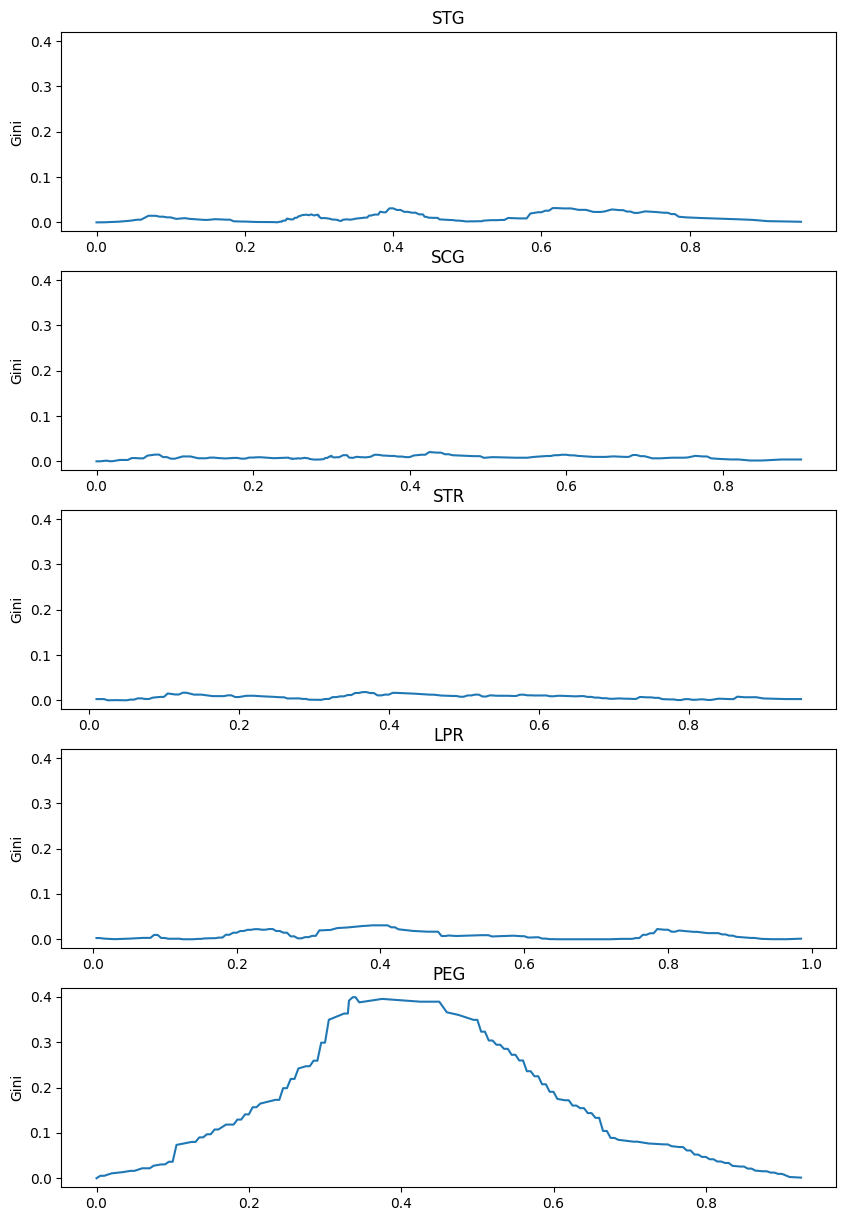

In [13]:
fig, ax = plt.subplots(5, 1, figsize=(10, 15), sharey=True)
columns = data.columns[:-1]
for i in range(5):
  x, y, _, _ = find_best_split(data[columns[i]], data["UNS"], task="classification")
  ax[i].plot(x, y)
  ax[i].set_ylabel('Gini')
  ax[i].set_title(columns[i])
plt.show()

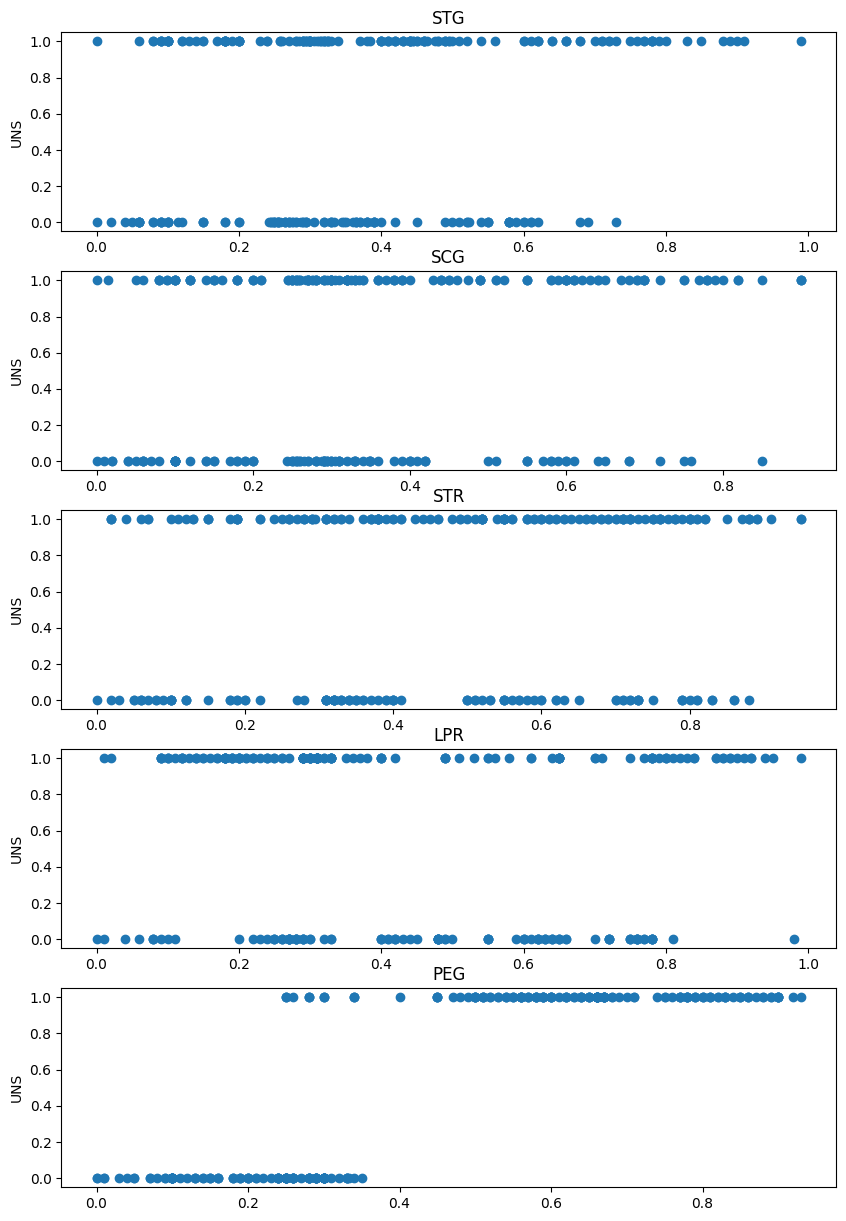

In [14]:
fig, ax = plt.subplots(5, 1, figsize=(10, 15),)
columns = data.columns[:-1]
for i in range(5):
  ax[i].scatter(data[columns[i]], data['UNS'])
  ax[i].set_ylabel('UNS')
  ax[i].set_title(columns[i])
plt.show()

Исходя из кривых значений критерия Джини, по какому признаку нужно производить деление выборки на два поддерева? Согласуется ли этот результат с визуальной оценкой диаграмм рассеяиния? Как бы охарактеризовали вид кривой для "хороших" признаков, по которым выборка делится почти идеально? Чем отличаются кривые для признаков, по которым деление практически невозможно?

Лучшим признаком является PEG. При его разбиении мы получаем наибольший критерий Джини около 0.4, при этом четко видна вершина графика, в районе порога 0.5. На диаграмме рассеяния также четко видно разделение на классы в окрестности точки 0.5. На идеальном графике должна быть четкая вершина (или плато), а также на диаграмме рассеяния должно быть видно четкое разделение классов по порогу. На остальных графиках много вершин, само значение критерия Джини значительно меньше, а на диаграммах рассеяния не видно порога, который четко бы разделял данные на два класса.

**Задание 2.4 (1 балл)** Протестируйте свое решающее дерево на датасете [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom).

1. Скачайте таблицу `agaricus-lepiota.data` (из [Data Folder](https://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/)),
2. Считайте таблицу при помощи `pandas`,
3. Примените к каждому столбцу `LabelEncoder` (из `sklearn`), чтобы преобразовать строковые имена категорий в натуральные числа.

Первый столбец — это целевая переменная (e — edible, p — poisonous) Мы будем измерять качество с помощью accuracy, так что нам не очень важно, что будет классом 1, а что — классом 0. Обучите решающее дерево на половине случайно выбранных объектов (признаки в датасете категориальные) и сделайте предсказания для оставшейся половины. Вычислите accuracy.

In [15]:
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/agaricus-lepiota.data
data = pd.read_csv('agaricus-lepiota.data')

--2025-04-04 09:37:52--  https://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/agaricus-lepiota.data
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘agaricus-lepiota.data’

agaricus-lepiota.da     [  <=>               ] 364.95K  1.47MB/s    in 0.2s    

2025-04-04 09:37:53 (1.47 MB/s) - ‘agaricus-lepiota.data’ saved [373704]



In [16]:
columns = [
    'class', 'cap_shape', 'cap_surface', 'cap_color', 'bruises', 'odor',
    'gill_attachment', 'gill_spacing', 'gill_size', 'gill_color',
    'stalk_shape', 'stalk_root', 'stalk_surface_above_ring',
    'stalk_surface_below_ring', 'stalk_color_above_ring',
    'stalk_color_below_ring', 'veil_type', 'veil_color', 'ring_number',
    'ring_type', 'spore_print_color', 'population', 'habitat'
]

data = pd.read_csv('agaricus-lepiota.data', header=None, names=columns)

print("Размер данных:", data.shape)
print("\nТипы данных:")
print(data.dtypes)
print("\nПервые строки данных:")
print(data.head())

Размер данных: (8124, 23)

Типы данных:
class                       object
cap_shape                   object
cap_surface                 object
cap_color                   object
bruises                     object
odor                        object
gill_attachment             object
gill_spacing                object
gill_size                   object
gill_color                  object
stalk_shape                 object
stalk_root                  object
stalk_surface_above_ring    object
stalk_surface_below_ring    object
stalk_color_above_ring      object
stalk_color_below_ring      object
veil_type                   object
veil_color                  object
ring_number                 object
ring_type                   object
spore_print_color           object
population                  object
habitat                     object
dtype: object

Первые строки данных:
  class cap_shape cap_surface cap_color bruises odor gill_attachment  \
0     p         x           s         n       

In [17]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

le = LabelEncoder()

for col in data.columns:
  data[col] = le.fit_transform(data[col])

print(data.head())

   class  cap_shape  cap_surface  cap_color  bruises  odor  gill_attachment  \
0      1          5            2          4        1     6                1   
1      0          5            2          9        1     0                1   
2      0          0            2          8        1     3                1   
3      1          5            3          8        1     6                1   
4      0          5            2          3        0     5                1   

   gill_spacing  gill_size  gill_color  ...  stalk_surface_below_ring  \
0             0          1           4  ...                         2   
1             0          0           4  ...                         2   
2             0          0           5  ...                         2   
3             0          1           5  ...                         2   
4             1          0           4  ...                         2   

   stalk_color_above_ring  stalk_color_below_ring  veil_type  veil_color  \
0         

In [18]:
X = data.drop('class', axis=1)
y = data['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(X_train.shape, X_test.shape)

(5686, 22) (2438, 22)


In [19]:
dt = DecisionTree(feature_types=['categorical']*22, task='classification')

dt.fit(X_train.values, y_train.values)

print('Accuracy =', accuracy_score(y_test.values, dt.predict(X_test.values)))

Accuracy = 1.0


## Часть 3: Бэггинг и случайный лес (4 балла)

В данной части мы будем работать [с задачей предсказания диабета у пациента](https://www.kaggle.com/uciml/pima-indians-diabetes-database/data). Посмотрим на работу бэггинга над решающими деревьями и случайного леса, сравним их работу.

In [20]:
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

In [21]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

columns = [
    'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
    'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'
]

data = pd.read_csv(url, header=None, names=columns)

print(f"Размер данных: {data.shape}")
print("\nТипы данных:")
print(data.dtypes)
print("\nПервые строки данных:")
print(data.head())

Размер данных: (768, 9)

Типы данных:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Первые строки данных:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32    

Посмотрим на распределение целевой переменной

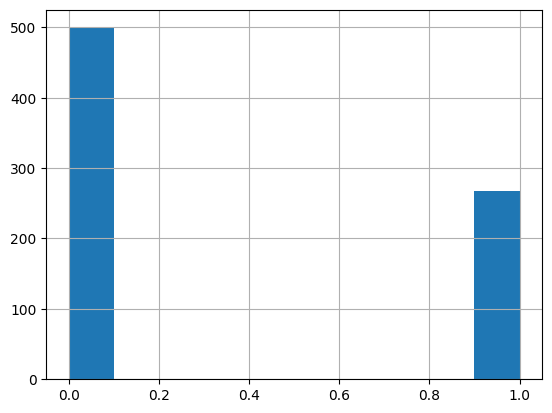

In [22]:
data['Outcome'].hist()
plt.show()

**Задание 3.1 (0.5 балла)** Разделите данные на признаки и целевую переменную. Разбейте датасет на обучающую и тестовую части в отношении 7:3. Затем разделите обучающую выборку на обучающую-обучающую и обучающую-валидационную в соотношении 7:3 (то есть в итоге должно получиться три выборки: обучающая-обучающая (0.49 от исходного датасета), обучающая-валидационная (0.21 от исходного датасета) и тестовая (0.3 от исходного датасета).

In [48]:
X = data.drop('Outcome', axis=1)
y = data['Outcome']

X_train1, X_test, y_train1, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train1, y_train1, test_size=0.3, random_state=42)
print(X_train.shape, X_val.shape, X_test.shape)

(375, 8) (162, 8) (231, 8)


**Задание 3.2 (1 балл)** На обучающей-валидационной выборке подберите оптимальные значения гиперпараметров `max_depth` и `min_samples_leaf` для `DecisionTreeClassifier`. Для этого:
1. Создайте списки с возможными значениями для перебора.
2. Для каждой пары значений обучите дерево на обучающей-обучающей выборке и определите качество на обучающей-валидационной выборке. В качестве критерия будем использовать `f1-меру`.
3. Выберите ту пару значений, которая даёт наилучшее качество на обучающей-валидационной выборке.


Обучите решающее дерево с подобранными гиперпараметрами на **полной обучающей** выборке. Оцените качество классификации на тестовой выборке по метрикам `accuracy`, `precision` и `recall`, `auc_roc`.

In [49]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score

In [50]:
max_depth_list = [3, 5, 7, 10, 15, 20]
min_samples_leaf_list = [1, 2, 5, 10, 15]

best_f1 = -1
best_depth = None
best_samples = None

for max_depth in max_depth_list:
  for min_samples_leaf in min_samples_leaf_list:
    model = DecisionTreeClassifier(max_depth=max_depth, min_samples_leaf=min_samples_leaf, random_state=42)
    model.fit(X_train, y_train)
    f1 = f1_score(y_val, model.predict(X_val))
    if f1 > best_f1:
      best_f1 = f1
      best_depth = max_depth
      best_samples = min_samples_leaf

print(f"Best f1 = {best_f1:.4f}")
print(f"Best max_depth = {best_depth}")
print(f"Best min_samples_leaf = {best_samples}")

Best f1 = 0.6667
Best max_depth = 5
Best min_samples_leaf = 5


In [51]:
best_model = DecisionTreeClassifier(max_depth=best_depth, min_samples_leaf=best_samples, random_state=42)
best_model.fit(X_train1, y_train1)
y_best_pred = best_model.predict(X_test)
y_best_pred_proba = best_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_best_pred)
precision = precision_score(y_test, y_best_pred)
recall = recall_score(y_test, y_best_pred)
roc_auc = roc_auc_score(y_test, y_best_pred_proba)

print("\nКачество лучшей модели на тестовой выборке:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")


Качество лучшей модели на тестовой выборке:
Accuracy: 0.7706
Precision: 0.7143
Recall: 0.5625
ROC-AUC: 0.7937


**Задание 3.3 (0.5 балла)** Обучите [`BaggingClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.BaggingClassifier.html) на 50 деревьях на **полной обучающей** выборке. Оцените качество классификации на тестовой выборке по тем же метрикам.

In [52]:
from sklearn.ensemble import BaggingClassifier

bc = BaggingClassifier(n_estimators=50, random_state=42)

bc.fit(X_train1, y_train1)

y_best_pred = bc.predict(X_test)
y_best_pred_proba = bc.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_best_pred)
precision = precision_score(y_test, y_best_pred)
recall = recall_score(y_test, y_best_pred)
roc_auc = roc_auc_score(y_test, y_best_pred_proba)

print("\nКачество BaggingClassifier на тестовой выборке:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")


Качество BaggingClassifier на тестовой выборке:
Accuracy: 0.7489
Precision: 0.6310
Recall: 0.6625
ROC-AUC: 0.8083


**Задание 3.4 (1 балл)** Выполните кросс-валидацию на полной обучающей выборке и подберите оптимальные значения гиперпараметров `max_depth` и `min_samples_split` для `Random Forest` с 50 деревьями. Для этого:

1. Создайте списки с возможными значениями для перебора.
2. Для каждой пары значений проведите кросс-валидацию на полной обучающей выборке. Количество разбиений выберите на ваш вкус. В качестве критерия будем использовать `f1-меру`. Усредните значение критерия по всем прогонам кросс-валидации.
3. Выберите ту пару значений, которая даёт наилучшее среднее качество.

Обучите случайный лес с подобранными гиперпараметрами на **полной обучающей** выборке. Оцените качество классификации по тем же метрикам. Какая из трёх построенных моделей показала себя лучше?

In [53]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

max_depth_list = [3, 5, 7, 10, 15, 20]
min_samples_leaf_list = [1, 2, 5, 10, 15]

best_f1 = -1
best_depth = None
best_samples = None
cv_folds = 5

for max_depth in max_depth_list:
  for min_samples_leaf in min_samples_leaf_list:
    model = RandomForestClassifier(n_estimators=50, max_depth=max_depth, min_samples_leaf=min_samples_leaf, random_state=42)
    model.fit(X_train, y_train)

    f1_scores = cross_val_score(model, X_train1, y_train1, cv=cv_folds, scoring="f1")
    f1 = np.mean(f1_scores)
    if f1 > best_f1:
      best_f1 = f1
      best_depth = max_depth
      best_samples = min_samples_leaf

print(f"Best f1 = {best_f1:.4f}")
print(f"Best max_depth = {best_depth}")
print(f"Best min_samples_leaf = {best_samples}")

Best f1 = 0.6460
Best max_depth = 15
Best min_samples_leaf = 5


In [57]:
best_model = RandomForestClassifier(n_estimators=50, max_depth=best_depth, min_samples_leaf=best_samples, random_state=42)
best_model.fit(X_train1, y_train1)
y_best_pred = best_model.predict(X_test)
y_best_pred_proba = best_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_best_pred)
precision = precision_score(y_test, y_best_pred)
recall = recall_score(y_test, y_best_pred)
roc_auc = roc_auc_score(y_test, y_best_pred_proba)

print("\nКачество лучшей модели на тестовой выборке:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")


Качество лучшей модели на тестовой выборке:
Accuracy: 0.7532
Precision: 0.6353
Recall: 0.6750
ROC-AUC: 0.8002


Нам нужно найти всех больных, чтобы назначить им правильное лечение. Поэтому из метрик нам важнее полнота. Наименьшая полнота у решающего дерева, всего 0.56. У бэггинга получше, 0.6625. Самая лучшая метрика у случайного леса, 0.6750. Это связано с тем, что в случайном лесу более независимые деревья, ковариация между ними меньше, что позволяет эффективнее снижать разброс.

**Задание 3.5 (0.5 балла)** Постройте график зависимости AUC ROC на тестовой выборке от числа деревьев (`n_estimators`) для случайного леса, обучаемого на **полной обучающей** выборке. Какие выводы можно сделать?

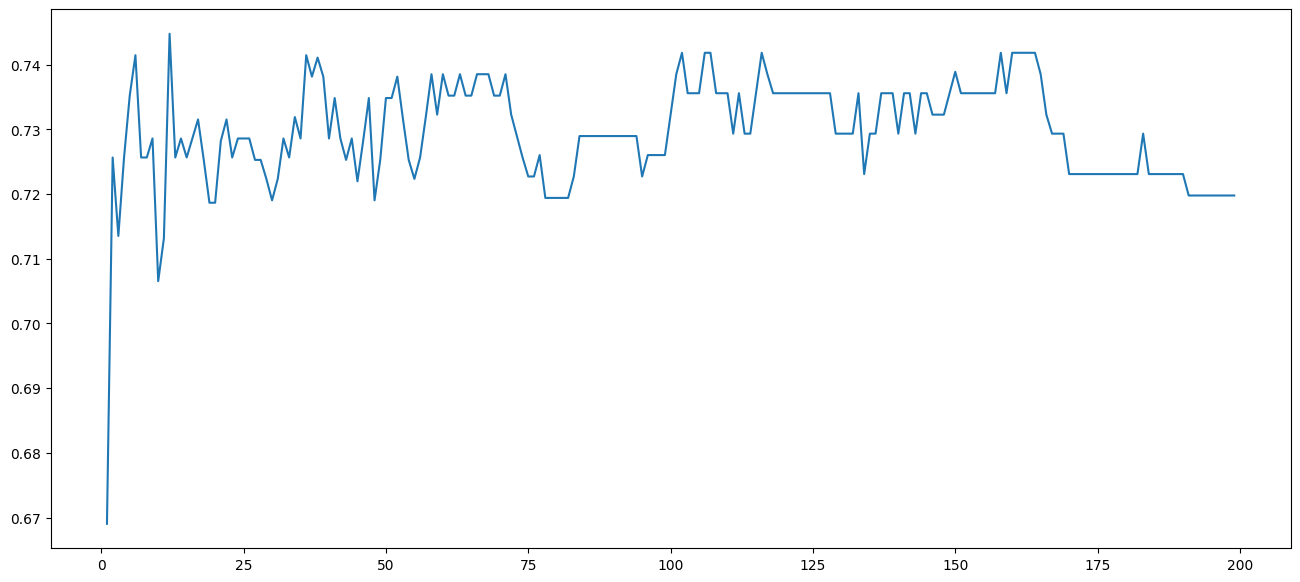

In [62]:
roc_auc_list = []

for i in np.arange(1, 200):
  rfc = RandomForestClassifier(n_estimators=i, max_depth=best_depth, min_samples_leaf=best_samples, random_state=42)
  rfc.fit(X_train1, y_train1)
  roc_auc_list.append(roc_auc_score(y_test, rfc.predict(X_test)))

plt.figure(figsize=(16, 7))
plt.plot(np.arange(1, 200), roc_auc_list);

Сначала ROC-AUC растет с ростом деревьев, а затем выходит на плато. Это показывает усточивость случайного леса к переобучению. Правда затем метрика слегка снижается, видимо переобучение все-таки имеет место

**Задание 3.6 (0.5 балла)** Для лучшей модели случайного леса из **Задания 3.4** посчитайте важность признаков и постройте bar plot. Какой признак оказался самым важным для определения диабета?

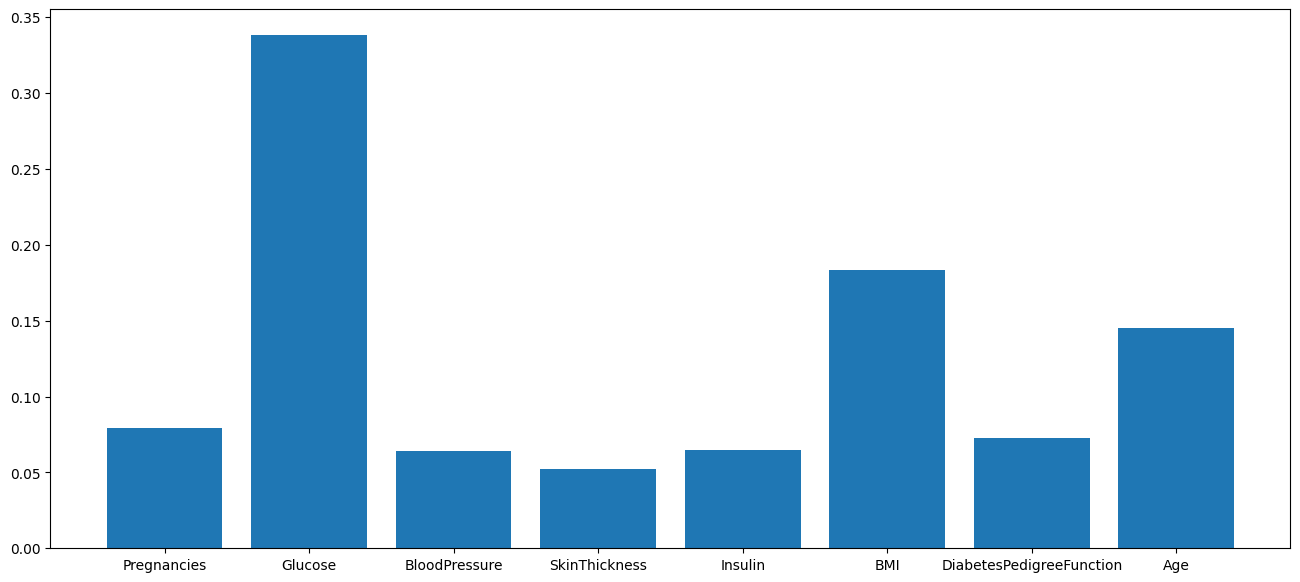

In [63]:
plt.figure(figsize=(16, 7))
plt.bar(X.columns, best_model.feature_importances_);

Вполне логично, что наиболее важным признаком оказалась глюкоза, а также индекс массы тела и возраст